# Customer Churn Prediction

## 1. Data Exploration

This notebook explores the Telco Customer Churn dataset before
data cleaning and model development.

### Objectives

- Understand the dataset structure
- Inspect data types
- Identify missing values
- Understand the target variable
- Examine class distribution

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.shape

(7043, 21)

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
df.describe(include="str")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [12]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [13]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [21]:
df["Churn"].value_counts(normalize=True) * 100# percentage

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

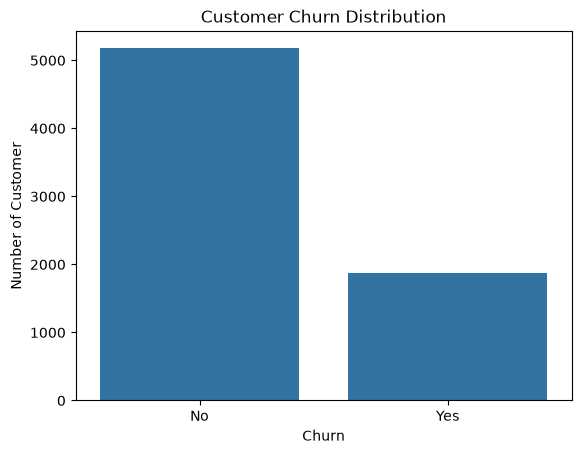

In [19]:
sns.countplot(data=df, x=df["Churn"])
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customer")
plt.show()

## Initial Observations

### Dataset

- Number of rows: 7043
- Number of columns: 21
- Target variable: `Churn`

### Variable types

#### Numerical
- `SeniorCitizen`
- `tenure`
- `MonthlyCharges`

#### Categorical
- `customerID`
- `gender`
- `Partner`
- `Dependents`
- `PhoneService`
- `MultipleLines`
- `InternetService`
- `OnlineSecurity`
- `OnlineBackup`
- `DeviceProtection`
- `TechSupport`
- `StreamingTV`
- `StreamingMovies`
- `Contract`
- `PaperlessBilling`
- `PaymentMethod`
- `TotalCharges`
- `Churn`

### Initial data quality observations
- No missing value so no cleaning to do
- Some columns needs to be converted into numerical values:>
- The target feature (churn) is imbalanced. ~73% of customers did not churn while ~26% churned

In [28]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [43]:
pd.to_numeric(df["TotalCharges"], errors="coerce").isnull().sum()

np.int64(11)

In [44]:
total_charges_numeric = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df[total_charges_numeric.isna()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [41]:
df[["SeniorCitizen", "tenure", "MonthlyCharges"]].describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


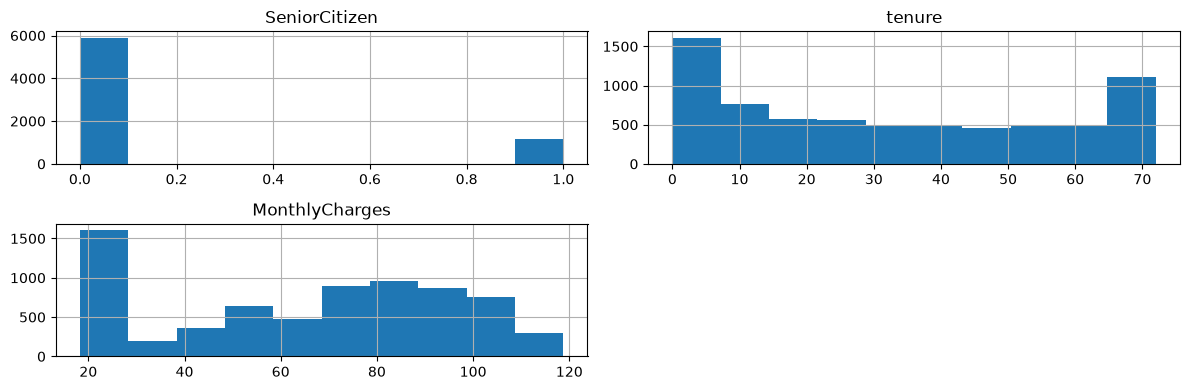

In [42]:
df[["SeniorCitizen", "tenure", "MonthlyCharges"]].hist(
    figsize=(12, 4)
)

plt.tight_layout()
plt.show()

In [45]:
df["customerID"].nunique()[]

7043

In [47]:
df["customerID"].duplicated().sum()

np.int64(0)

In [48]:
df[["SeniorCitizen", "tenure", "MonthlyCharges"]].describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


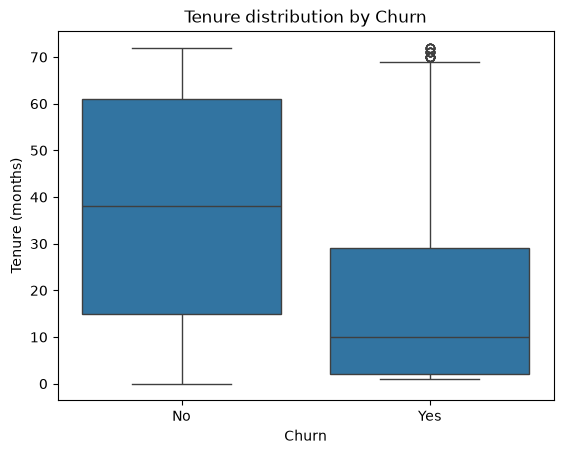

In [52]:
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.show()

In [93]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [95]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"]
)

In [96]:
df["tenure_group"]

0        0-12
1       25-48
2        0-12
3       25-48
4        0-12
        ...  
7038    13-24
7039    49-72
7040     0-12
7041     0-12
7042    49-72
Name: tenure_group, Length: 7043, dtype: category
Categories (4, str): ['0-12' < '13-24' < '25-48' < '49-72']

In [71]:
tenure_churn = pd.crosstab(
    df["tenure_group"],
    df["Churn"],
    normalize="index"
) * 100

tenure_churn

Churn,No,Yes
tenure_group,,
0-12,52.561757,47.438243
13-24,71.289062,28.710938
25-48,79.611041,20.388959
49-72,90.486824,9.513176


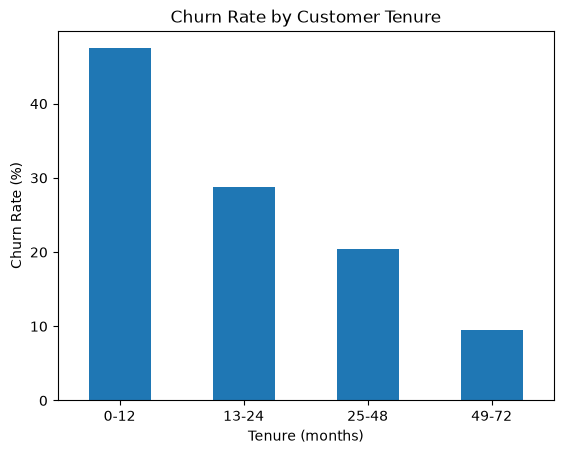

In [98]:
tenure_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [106]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [135]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [108]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


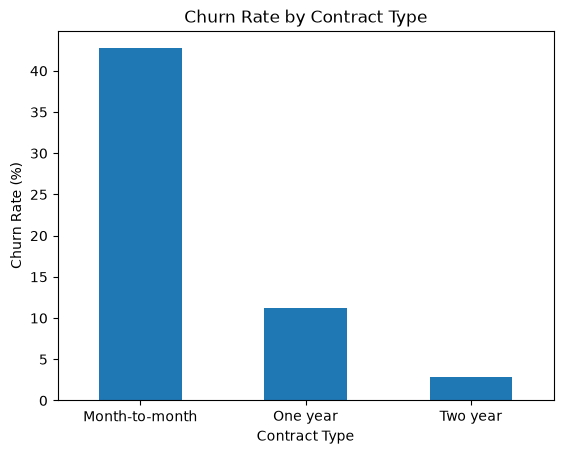

In [112]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

- Which contract has the highest churn rate? `Month-to-month`
- Which has the lowest? `Two year`
### Data quality
- TotalCharges contains 11 blank string values and it correspond to customer with zero tenure timee

In [119]:
pd.crosstab(
    df["Contract"],
    df["tenure_group"],
    normalize="index"
) * 100

tenure_group,0-12,13-24,25-48,49-72
Contract,,,,
Month-to-month,51.458065,19.019355,20.696774,8.825806
One year,8.418194,13.374067,35.166327,43.041412
Two year,4.011799,5.309735,16.165192,74.513274


In [120]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   str     
 1   gender            7043 non-null   str     
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   str     
 4   Dependents        7043 non-null   str     
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   str     
 7   MultipleLines     7043 non-null   str     
 8   InternetService   7043 non-null   str     
 9   OnlineSecurity    7043 non-null   str     
 10  OnlineBackup      7043 non-null   str     
 11  DeviceProtection  7043 non-null   str     
 12  TechSupport       7043 non-null   str     
 13  StreamingTV       7043 non-null   str     
 14  StreamingMovies   7043 non-null   str     
 15  Contract          7043 non-null   str     
 16  PaperlessBilling  7043 non-null   s

In [137]:
pd.crosstab(df["Contract"], df["tenure_group"], normalize="index") * 100

tenure_group,0-12,13-24,25-48,49-72
Contract,,,,
Month-to-month,51.458065,19.019355,20.696774,8.825806
One year,8.418194,13.374067,35.166327,43.041412
Two year,4.011799,5.309735,16.165192,74.513274


In [141]:
pd.crosstab(
    [df["Contract"], df["tenure_group"]],
    df["Churn"],
    normalize="index"
) * 100

Churn                                No        Yes
Contract       tenure_group                       
Month-to-month 0-12           48.645938  51.354062
               13-24          62.279512  37.720488
               25-48          67.082294  32.917706
               49-72          73.976608  26.023392
One year       0-12           89.516129  10.483871
               13-24          91.878173   8.121827
               25-48          89.382239  10.617761
               49-72          87.066246  12.933754
Two year       0-12          100.000000   0.000000
               13-24         100.000000   0.000000
               25-48          97.810219   2.189781
               49-72          96.674584   3.325416

In [142]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [143]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


Variable	Observation
- `tenure`	Shorter-tenure customers churn substantially more
- `Contract`	Month-to-month customers churn substantially more
- `InternetService`	Fiber-optic customers have substantially higher churn
- `PaymentMethod`	Electronic-check customers have substantially higher churn

In [144]:
df.groupby("Churn")[["tenure", "MonthlyCharges"]].mean()

,tenure,MonthlyCharges
Churn,,
No,37.569965,61.265124
Yes,17.979133,74.441332


In [145]:
df.groupby("Churn")[["tenure", "MonthlyCharges"]].median()

,tenure,MonthlyCharges
Churn,,
No,38.0,64.425
Yes,10.0,79.650


In [146]:
df.groupby("Churn")[["tenure", "MonthlyCharges"]].describe()

tenure                                                     \
        count       mean        std  min   25%   50%   75%   max   
Churn                                                              
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0   
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0   

      MonthlyCharges                                                            
               count       mean        std    min    25%     50%   75%     max  
Churn                                                                           
No            5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75  
Yes           1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35

In [147]:
df[["tenure", "MonthlyCharges"]].corr()

,tenure,MonthlyCharges
tenure,1.0000,0.2479
MonthlyCharges,0.2479,1.0000


In [148]:
df.groupby("tenure_group")["MonthlyCharges"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
tenure_group,,,
0-12,2186,56.097781,55.9
13-24,1024,61.357275,66.4
25-48,1594,65.930552,72.9
49-72,2239,73.945377,82.5


In [149]:
df.groupby(["tenure_group", "Churn"])["MonthlyCharges"].mean()

tenure_group  Churn
0-12          No       46.714970
              Yes      66.493973
13-24         No       54.449589
              Yes      78.509014
25-48         No       61.174783
              Yes      84.500000
49-72         No       72.029245
              Yes      92.171127
Name: MonthlyCharges, dtype: float64